<a href="https://colab.research.google.com/github/oguzhanerbil/food-health-predictor/blob/Zeynep/prediction/albert/albertmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kütüphaneler

In [ ]:
!pip install transformers -q

import time, warnings, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_curve, auc as sk_auc
from transformers import (AlbertTokenizer, AlbertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback)

print("✅ Kütüphaneler hazır")

✅ Kütüphaneler hazır


Veri Yükleme ve Ön İşleme

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

if df["nutriscore_notu"].dtype in [float, int]:
    df["nutriscore_notu"] = df["nutriscore_notu"].map(
        {0.0:"A", 1.0:"B", 2.0:"C", 3.0:"D", 4.0:"E"})

df["label"] = df["nutriscore_notu"].map({"A":0,"B":1,"C":2,"D":3,"E":4})
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

df["text"] = (
    "Energy: "      + df["enerji_kcal"].fillna(0).astype(str)    + " kcal. "
    + "Fat: "       + df["yag_g"].fillna(0).astype(str)          + "g. "
    + "Saturated: " + df["doymus_yag_g"].fillna(0).astype(str)   + "g. "
    + "Carbs: "     + df["karbonhidrat_g"].fillna(0).astype(str) + "g. "
    + "Sugar: "     + df["seker_g"].fillna(0).astype(str)        + "g. "
    + "Fiber: "     + df["lif_g"].fillna(0).astype(str)          + "g. "
    + "Protein: "   + df["protein_g"].fillna(0).astype(str)      + "g. "
    + "Salt: "      + df["tuz_g"].fillna(0).astype(str)          + "g. "
    + "Nova: "      + df["nova_grubu"].fillna(0).astype(str)     + "."
)

print("✅ Veri boyutu:", df.shape)
print(df["nutriscore_notu"].value_counts())

Saving data.csv to data.csv
✅ Veri boyutu: (64604, 27)
nutriscore_notu
B    15207
E    13046
C    13005
A    11939
D    11407
Name: count, dtype: int64


Sınıf Ağırlıkları + Dataset + Trainer Tanımları

In [ ]:
class_weights = compute_class_weight("balanced",
    classes=np.array([0,1,2,3,4]), y=df["label"].values)
weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Sınıf ağırlıkları:", dict(zip("ABCDE", class_weights.round(2))))

class NutriDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=self.class_weights_tensor.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}

print("✅ Sınıflar tanımlandı")

Sınıf ağırlıkları: {'A': np.float64(1.08), 'B': np.float64(0.85), 'C': np.float64(0.99), 'D': np.float64(1.13), 'E': np.float64(0.99)}
✅ Sınıflar tanımlandı


5-Fold CV Eğitimi

In [ ]:
tokenizer = AlbertTokenizer.from_pretrained("albert-base-v2")
texts  = df["text"].tolist()
labels = df["label"].tolist()
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_fold_metrics, all_train_losses, all_val_losses = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n{'='*45} FOLD {fold+1}/5 {'='*45}")

    tr_enc = tokenizer([texts[i] for i in train_idx], truncation=True, padding=True, max_length=128)
    vl_enc = tokenizer([texts[i] for i in val_idx],   truncation=True, padding=True, max_length=128)
    tr_ds  = NutriDataset(tr_enc, [labels[i] for i in train_idx])
    vl_ds  = NutriDataset(vl_enc, [labels[i] for i in val_idx])

    model = AlbertForSequenceClassification.from_pretrained("albert-base-v2", num_labels=5)

    trainer = WeightedTrainer(
        class_weights_tensor=weights_tensor,
        model=model,
        args=TrainingArguments(
            output_dir=f"./fold{fold+1}",
            num_train_epochs=5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            learning_rate=2e-5,
            warmup_steps=100,
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            logging_steps=50,
            report_to="none",
            fp16=torch.cuda.is_available(),
        ),
        train_dataset=tr_ds,
        eval_dataset=vl_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    logs = trainer.state.log_history
    all_train_losses.append([(x["epoch"], x["loss"])      for x in logs if "loss" in x and "eval_loss" not in x])
    all_val_losses.append(  [(x["epoch"], x["eval_loss"]) for x in logs if "eval_loss" in x])

    t1 = time.time()
    out = trainer.predict(vl_ds)
    infer_time = time.time() - t1

    preds, true = np.argmax(out.predictions, axis=1), out.label_ids
    y_bin  = label_binarize(true, classes=[0,1,2,3,4])
    y_prob = torch.softmax(torch.tensor(out.predictions), dim=1).numpy()
    cm_f   = confusion_matrix(true, preds, labels=[0,1,2,3,4])
    TN = cm_f.sum() - (cm_f.sum(axis=1) + cm_f.sum(axis=0) - np.diag(cm_f))
    FP = cm_f.sum(axis=0) - np.diag(cm_f)

    all_fold_metrics.append({
        "fold": fold+1,
        "accuracy":    accuracy_score(true, preds),
        "precision":   precision_score(true, preds, average="macro", zero_division=0),
        "recall":      recall_score(true, preds, average="macro", zero_division=0),
        "f1_macro":    f1_score(true, preds, average="macro", zero_division=0),
        "sensitivity": recall_score(true, preds, average="macro", zero_division=0),
        "specificity": (TN/(TN+FP+1e-9)).mean(),
        "auc":         roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro"),
        "training_time_s":  train_time,
        "inference_time_s": infer_time,
    })
    m = all_fold_metrics[-1]
    print(f"  Acc:{m['accuracy']:.4f} | F1:{m['f1_macro']:.4f} | AUC:{m['auc']:.4f}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]


============================================= FOLD 1/5 =============================================


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Acc:0.8325 | F1:0.8341 | AUC:0.9697


5-Fold Sonuç Tablosu

In [ ]:
results_df = pd.DataFrame(all_fold_metrics)
cols = ["fold","accuracy","precision","recall","f1_macro",
        "sensitivity","specificity","auc","training_time_s","inference_time_s"]
print(results_df[cols].to_string(index=False))
print("\n── Ortalama ──")
print(results_df[cols[1:]].mean().round(4))

 fold  accuracy  precision   recall  f1_macro  sensitivity  specificity      auc  training_time_s  inference_time_s
    1  0.834920   0.836133 0.837470  0.836511     0.837470     0.958556 0.970941      2263.299924         37.318146
    2  0.836545   0.837751 0.839607  0.838224     0.839607     0.958978 0.971266      2225.019143         38.119208
    3  0.836932   0.837617 0.840917  0.838750     0.840917     0.959111 0.971336      2271.259852         37.083065
    4  0.829425   0.830513 0.832888  0.831414     0.832888     0.957181 0.969880      2260.499828         36.801759
    5  0.832508   0.833440 0.835269  0.834115     0.835269     0.957967 0.969695      2260.584610         37.337332

── Ortalama ──
accuracy               0.8341
precision              0.8351
recall                 0.8372
f1_macro               0.8358
sensitivity            0.8372
specificity            0.9584
auc                    0.9706
training_time_s     2256.1327
inference_time_s      37.3319
dtype: float64


Loss Grafikleri (Epoch Bazlı)

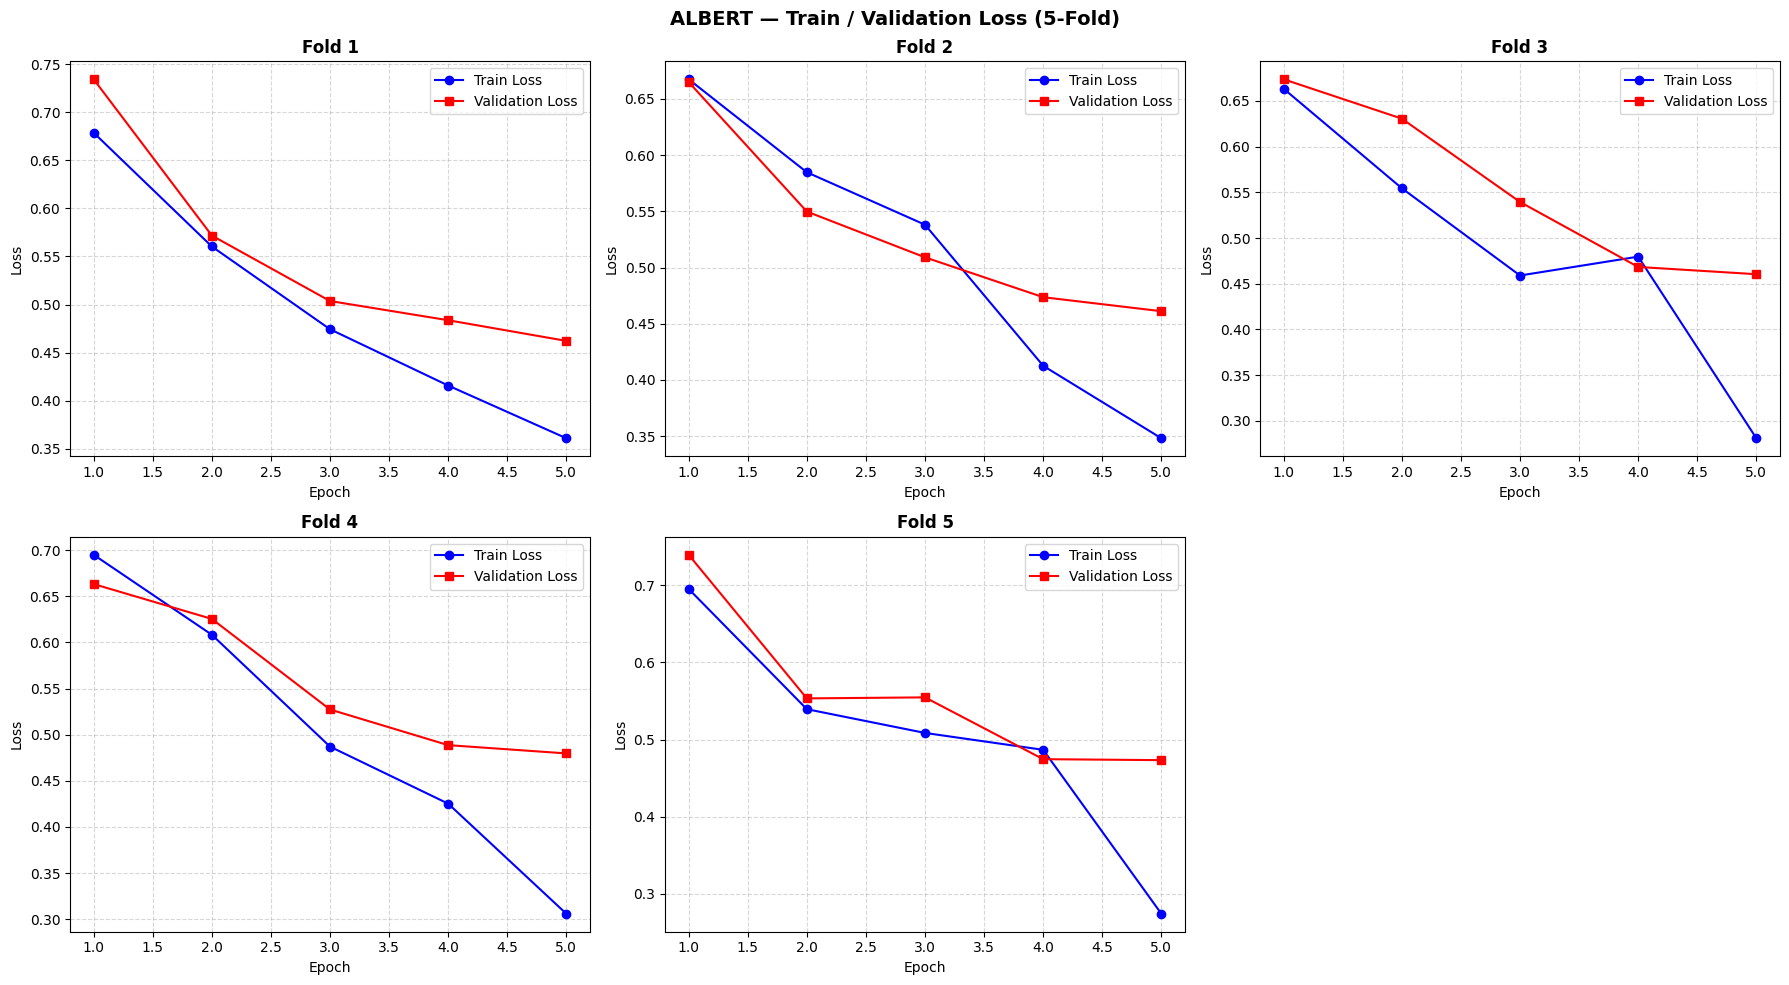

✅ Kaydedildi: albert_loss_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]

    # Train loss — epoch bazlı (her epoch'un son adımı)
    if all_train_losses[i]:
        ep_arr  = np.array([x[0] for x in all_train_losses[i]])
        val_arr = np.array([x[1] for x in all_train_losses[i]])
        epoch_ends = []
        for e in range(1, 6):
            mask = (ep_arr > e-1) & (ep_arr <= e)
            if mask.any():
                epoch_ends.append((e, val_arr[mask][-1]))
        if epoch_ends:
            ep2, vals2 = zip(*epoch_ends)
            ax.plot(ep2, vals2, "b-o", markersize=6, label="Train Loss")

    # Validation loss
    if all_val_losses[i]:
        ep, vals = zip(*all_val_losses[i])
        ax.plot(ep, vals, "r-s", markersize=6, label="Validation Loss")

    ax.set_title(f"Fold {i+1}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

axes[5].set_visible(False)
plt.suptitle("ALBERT — Train / Validation Loss (5-Fold)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("albert_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Kaydedildi: albert_loss_curves.png")

Final Model Eğitimi

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42)

tr_enc = tokenizer(X_tr, truncation=True, padding=True, max_length=128)
te_enc = tokenizer(X_te, truncation=True, padding=True, max_length=128)
tr_ds  = NutriDataset(tr_enc, y_tr)
te_ds  = NutriDataset(te_enc, y_te)

final_model = AlbertForSequenceClassification.from_pretrained("albert-base-v2", num_labels=5)

final_trainer = WeightedTrainer(
    class_weights_tensor=weights_tensor,
    model=final_model,
    args=TrainingArguments(
        output_dir="./final_model",
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        warmup_steps=100,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available(),
    ),
    train_dataset=tr_ds,
    eval_dataset=te_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

t0 = time.time()
final_trainer.train()
final_train_time = time.time() - t0

t1 = time.time()
final_preds = final_trainer.predict(te_ds)
final_infer_time = time.time() - t1

y_pred = np.argmax(final_preds.predictions, axis=1)
y_true = final_preds.label_ids
y_prob = torch.softmax(torch.tensor(final_preds.predictions), dim=1).numpy()
y_bin  = label_binarize(y_true, classes=[0,1,2,3,4])

print(classification_report(y_true, y_pred, target_names=list("ABCDE"), zero_division=0))
print(f"✅ Training time: {final_train_time:.1f}s | Inference time: {final_infer_time:.3f}s")

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.691114,0.689534,0.719913,0.724899
2,0.550622,0.577127,0.779197,0.781310
3,0.472421,0.532096,0.793824,0.796917
4,0.391675,0.489319,0.812553,0.813905
5,0.407734,0.474645,0.830199,0.831799


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           A       0.80      0.86      0.83      2388
           B       0.81      0.77      0.79      3042
           C       0.78      0.78      0.78      2601
           D       0.85      0.84      0.84      2281
           E       0.92      0.91      0.92      2609

    accuracy                           0.83     12921
   macro avg       0.83      0.83      0.83     12921
weighted avg       0.83      0.83      0.83     12921

✅ Training time: 2265.4s | Inference time: 36.769s


Confusion Matrix

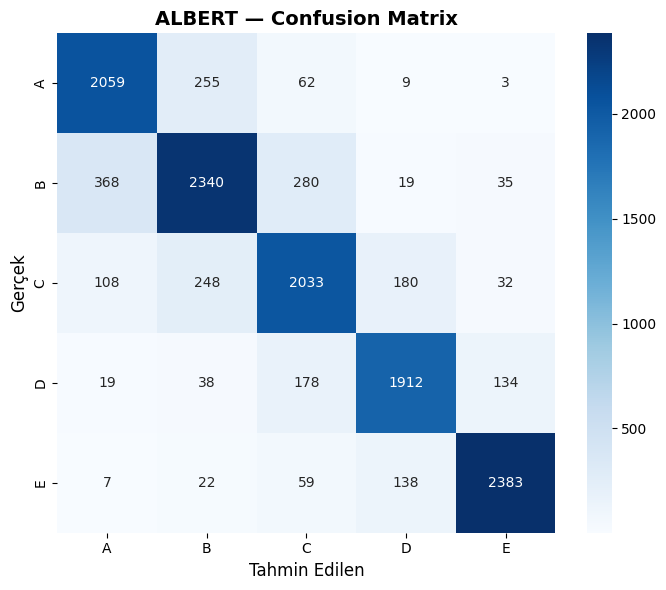

✅ Kaydedildi: albert_confusion_matrix.png


In [ ]:
# Final model tahminleri kullanılıyor
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list("ABCDE"), yticklabels=list("ABCDE"), ax=ax)
ax.set_xlabel("Tahmin Edilen", fontsize=12)
ax.set_ylabel("Gerçek", fontsize=12)
ax.set_title("ALBERT — Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("albert_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Kaydedildi: albert_confusion_matrix.png")

ROC Eğrisi

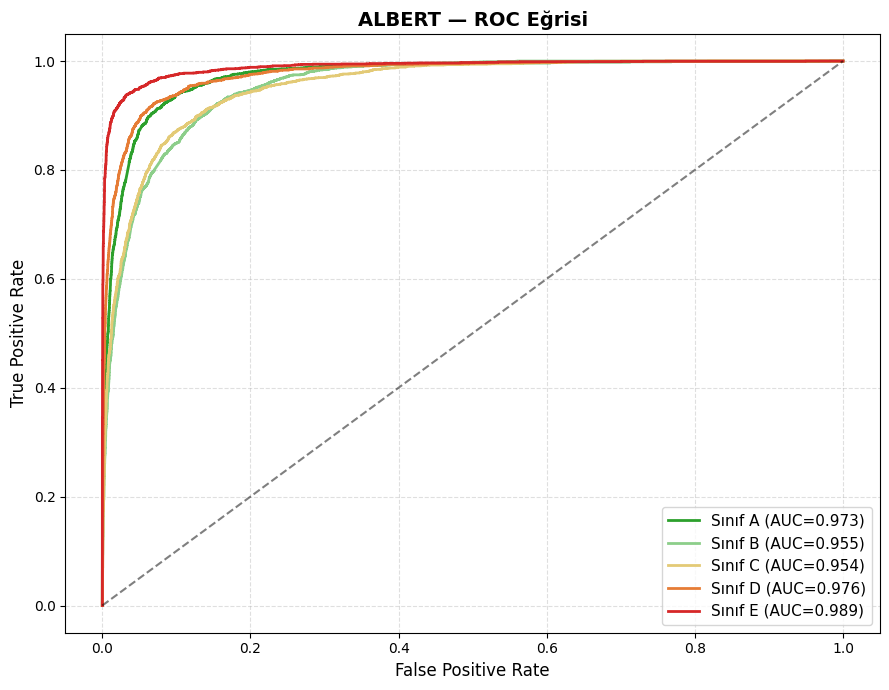

✅ Kaydedildi: albert_roc_curve.png


In [ ]:
colors = ["#2ca02c","#8cce8a","#e3ca76","#e67c35","#d62728"]
fig, ax = plt.subplots(figsize=(9, 7))
for i, (c, lbl) in enumerate(zip(colors, "ABCDE")):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=c, lw=2, label=f"Sınıf {lbl} (AUC={sk_auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],"k--", alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ALBERT — ROC Eğrisi", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("albert_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Kaydedildi: albert_roc_curve.png")

Final Metrik Tablosu

In [ ]:
TN = cm.sum() - (cm.sum(axis=1) + cm.sum(axis=0) - np.diag(cm))
FP = cm.sum(axis=0) - np.diag(cm)
spec = (TN / (TN + FP + 1e-9)).mean()

final_summary = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall (Sensitivity)","F1-Score",
               "Specificity","AUC","Training Time (s)","Inference Time (s)"],
    "Value": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="macro", zero_division=0),
        recall_score(y_true, y_pred, average="macro", zero_division=0),
        f1_score(y_true, y_pred, average="macro", zero_division=0),
        spec,
        roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro"),
        final_train_time,
        final_infer_time,
    ]
})
print(final_summary.to_string(index=False))
print("\n✅ ALBERT tamamen tamamlandı!")

              Metric       Value
            Accuracy    0.830199
           Precision    0.831258
Recall (Sensitivity)    0.832937
            F1-Score    0.831799
         Specificity    0.957389
                 AUC    0.969446
   Training Time (s) 2265.433115
  Inference Time (s)   36.769157

✅ ALBERT tamamen tamamlandı!
